In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [6]:
data = pd.read_csv("loan approval data.csv")
data.head()
data.info()
data.isnull().sum()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


### >>> Handling Missing Values

In [3]:
categorical_cols = data.select_dtypes(include=['object']).columns
# numerical_cols = data.select_dtypes(include=['float64']).columns
numerical_cols = data.select_dtypes(include=['number']).columns

categorical_cols
numerical_cols

categorical_cols.size + numerical_cols.size

20

In [4]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
# num_imputer.fit_transform(data[numerical_cols])
data[numerical_cols] = num_imputer.fit_transform(data[numerical_cols])  #to make changes in final dataset

cat_imputer = SimpleImputer(strategy='most_frequent')
data[categorical_cols] = cat_imputer.fit_transform(data[categorical_cols])  #to make changes in final dataset

data.head()
data.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

### >>> EDA - Exploratory Data Analysis
##### To find the relation between the features - How and which features are more imp. to contribute in predicting the output.

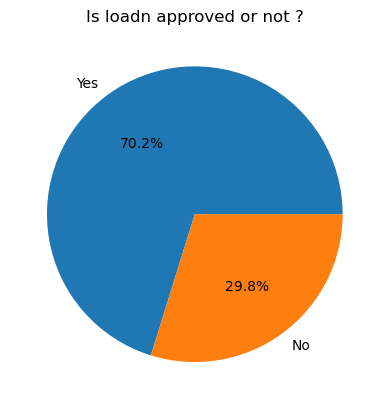

In [5]:
# How balanced our classes are ?

classes_count = data["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["Yes", "No"], autopct='%1.1f%%')
plt.title("Is loadn approved or not ?")
plt.show()


[Text(0, 0, '621'), Text(0, 0, '379')]

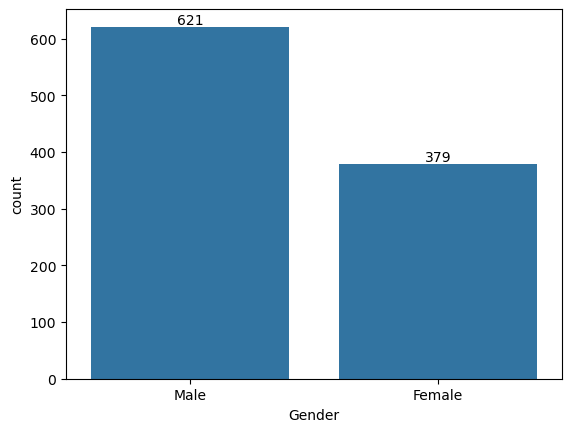

In [6]:
# analyze gender categories

gender_cnt = data["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])


[Text(0, 0, '722'), Text(0, 0, '278')]

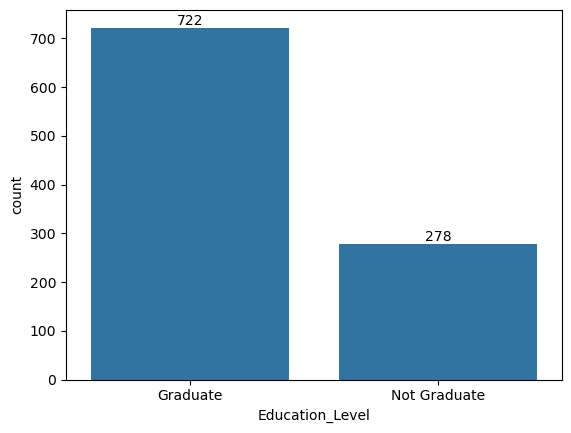

In [7]:
# Analyze the education level of the applicants

edu_cnt = data["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])


<Axes: xlabel='Applicant_Income', ylabel='Count'>

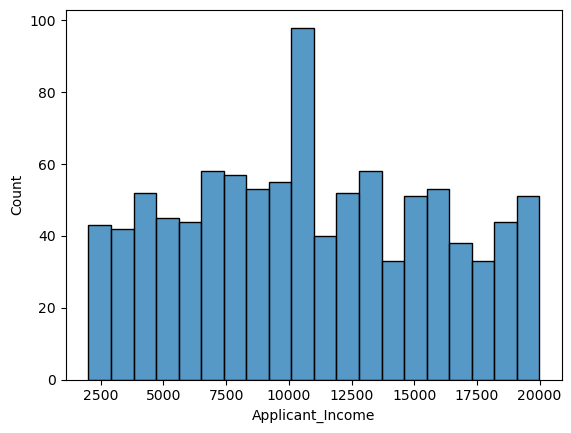

In [8]:
#Analyze income of applicant
sns.histplot(
    data = data,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

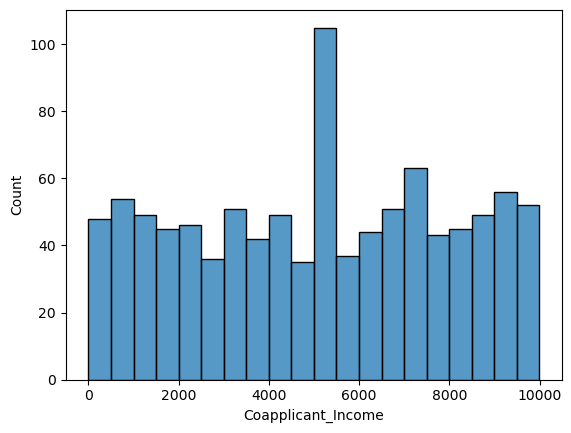

In [9]:
#Analyze income of Coapplicant
sns.histplot(
    data = data,
    x = "Coapplicant_Income",
    bins = 20
)

In [10]:
# Outllier - box plots

data.head()

# sns.boxplot(
#     data = data,
#     x = "Loan_Approved",
#     y = "Applicant_Income"
# )

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


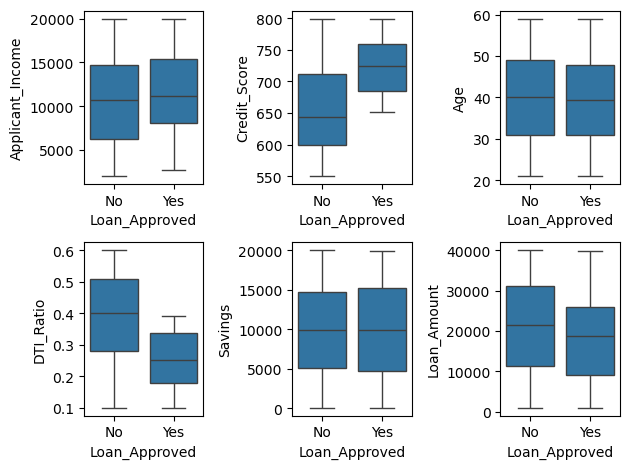

In [11]:
fig, axes= plt.subplots(2,3)

sns.boxplot(ax=axes[0,0], data = data, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax=axes[0,1], data = data, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax=axes[1,0], data = data, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax=axes[1,1], data = data, x = "Loan_Approved", y = "Savings")
sns.boxplot(ax=axes[0,2], data = data, x = "Loan_Approved", y = "Age")
sns.boxplot(ax=axes[1,2], data = data, x = "Loan_Approved", y = "Loan_Amount")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

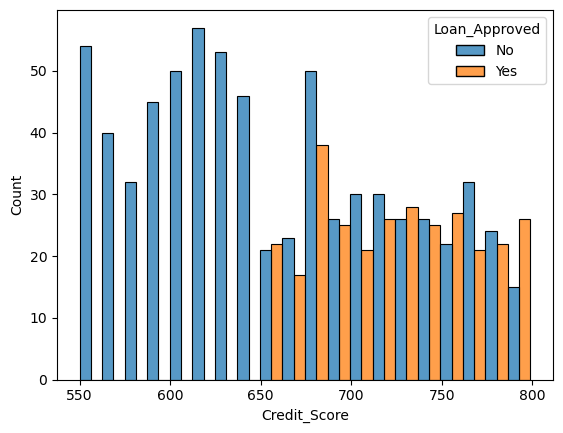

In [12]:
# Credit Score with Loan Approved

#Analyze income
sns.histplot(
    data = data,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)  


<Axes: xlabel='Applicant_Income', ylabel='Count'>

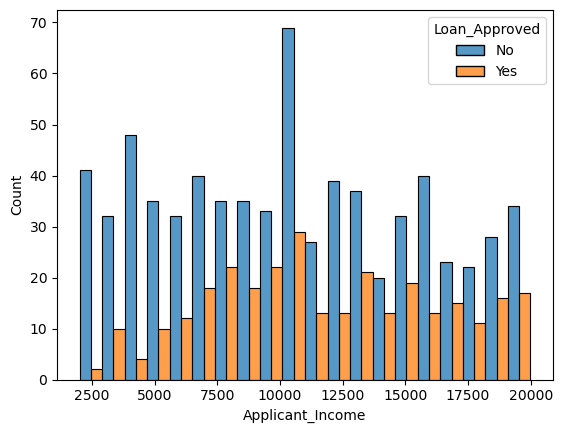

In [13]:
# Applicant Income with Loan Approved

#Analyze income
sns.histplot(
    data = data,
    x = "Applicant_Income",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)  


In [36]:
# Removing Applicant Id
data = data.drop("Applicant_ID", axis=1)
data.head()
# data.shape


,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Property_Area_nan,Gender_Male,Gender_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


### >>> Encoding
##### Converting the non numeric feature values into numeric values.|

In [41]:
data.head()
# data.shape
# data.columns
# data.info()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Property_Area_nan,Gender_Male,Gender_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [44]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


le = LabelEncoder()
data["Education_Level"] = le.fit_transform(data["Education_Level"])
data["Loan_Approved"] = le.fit_transform(data["Loan_Approved"])


In [45]:
data.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Property_Area_nan,Gender_Male,Gender_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [16]:

cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(data[cols])

# encoded
# ohe.get_feature_names_out(cols)

encoded_data = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index = data.index)

# encoded_data.head()

data = pd.concat([data.drop(columns=cols), encoded_data], axis=1)

# data.head()

In [46]:
# encoded
# ohe.get_feature_names_out(cols)
# encoded_data.head()

data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 950 non-null    float64
 1   Coapplicant_Income               950 non-null    float64
 2   Age                              950 non-null    float64
 3   Dependents                       950 non-null    float64
 4   Credit_Score                     950 non-null    float64
 5   Existing_Loans                   950 non-null    float64
 6   DTI_Ratio                        950 non-null    float64
 7   Savings                          950 non-null    float64
 8   Collateral_Value                 950 non-null    float64
 9   Loan_Amount                      950 non-null    float64
 10  Loan_Term                        950 non-null    float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

### >>> Correlation Heatpmap 
##### - Correlation heatmap shows how strongly features are related to each other.
##### - Correlation shows the linear relation b/w the features, it also shows the non-linear relation b/w the features but majorly shows the linear relation.

In [47]:
# Filtering the all numerical value columns
num_cols = data.select_dtypes(include=['number'])
corr_matrix = num_cols.corr()


corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Property_Area_nan,Gender_Male,Gender_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan
Applicant_Income,1.000000,0.007860,-0.025458,-0.028181,-0.010352,-0.010993,-0.009625,-0.029615,0.019734,-0.025187,...,0.005031,-0.012199,-0.058237,-0.022989,0.004469,-0.025557,0.105836,-0.046846,-0.012141,-0.000036
Coapplicant_Income,0.007860,1.000000,0.015098,-0.028062,0.060981,0.013156,0.061397,-0.015872,0.010070,0.001650,...,-0.010468,0.052011,-0.047246,0.010724,-0.047766,-0.001173,0.038712,-0.004863,-0.048740,0.020718
Age,-0.025458,0.015098,1.000000,-0.019788,-0.004425,0.024691,0.008359,-0.001037,0.039301,0.014292,...,0.003165,-0.034233,0.017855,0.048610,0.000168,-0.068697,0.021770,-0.016579,0.073002,0.006529
Dependents,-0.028181,-0.028062,-0.019788,1.000000,-0.007976,-0.027991,0.011970,-0.005253,0.024134,-0.018258,...,-0.033520,0.016697,0.018330,0.035691,-0.049718,-0.009381,-0.019351,0.040217,-0.056425,-0.018954
Credit_Score,-0.010352,0.060981,-0.004425,-0.007976,1.000000,-0.007444,0.002449,-0.069286,0.008280,0.000957,...,-0.007150,-0.004053,0.020043,-0.049799,0.022356,-0.007259,0.069063,0.012313,-0.048025,-0.027074
Existing_Loans,-0.010993,0.013156,0.024691,-0.027991,-0.007444,1.000000,0.049748,0.036499,-0.052752,-0.022430,...,-0.054971,0.055556,-0.043170,-0.036528,-0.005557,-0.009815,0.031486,-0.029996,0.047300,0.021845
DTI_Ratio,-0.009625,0.061397,0.008359,0.011970,0.002449,0.049748,1.000000,0.004902,-0.010031,0.079525,...,0.046420,0.002827,-0.020648,0.005504,0.009726,-0.007414,0.002123,0.006472,0.026212,-0.023598
Savings,-0.029615,-0.015872,-0.001037,-0.005253,-0.069286,0.036499,0.004902,1.000000,0.016258,-0.012924,...,0.005586,0.044871,-0.064076,0.006320,-0.029420,-0.012079,0.004465,-0.018468,0.027770,-0.028833
Collateral_Value,0.019734,0.010070,0.039301,0.024134,0.008280,-0.052752,-0.010031,0.016258,1.000000,0.002754,...,0.020607,0.008409,-0.000478,-0.008867,0.022752,0.036611,-0.013848,-0.026135,-0.009913,0.024370
Loan_Amount,-0.025187,0.001650,0.014292,-0.018258,0.000957,-0.022430,0.079525,-0.012924,0.002754,1.000000,...,0.041211,-0.061248,0.022599,0.070596,0.076364,0.013368,-0.026633,0.022465,-0.027276,-0.017039


In [22]:
# Checking relation of features with the output feature that is "Loan_Approved"
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.404817
Applicant_Income                   0.099770
Employer_Category_MNC              0.062015
Marital_Status_Single              0.053416
Collateral_Value                   0.040321
Employment_Status_nan              0.040155
Loan_Purpose_nan                   0.040155
Employer_Category_Private          0.035304
Gender_nan                         0.032282
Loan_Purpose_Personal              0.027617
Coapplicant_Income                 0.026428
Dependents                         0.022332
Applicant_ID                       0.021234
Loan_Purpose_Education             0.013201
Property_Area_Urban                0.010779
Property_Area_nan                  0.008661
Loan_Purpose_Home                  0.006036
Employment_Status_Self-employed   -0.001939
Marital_Status_nan                -0.007086
Property_Area_Semiurban           -0.014122
Education_Level                   -0.019102
Gender_Male                     

<Axes: >

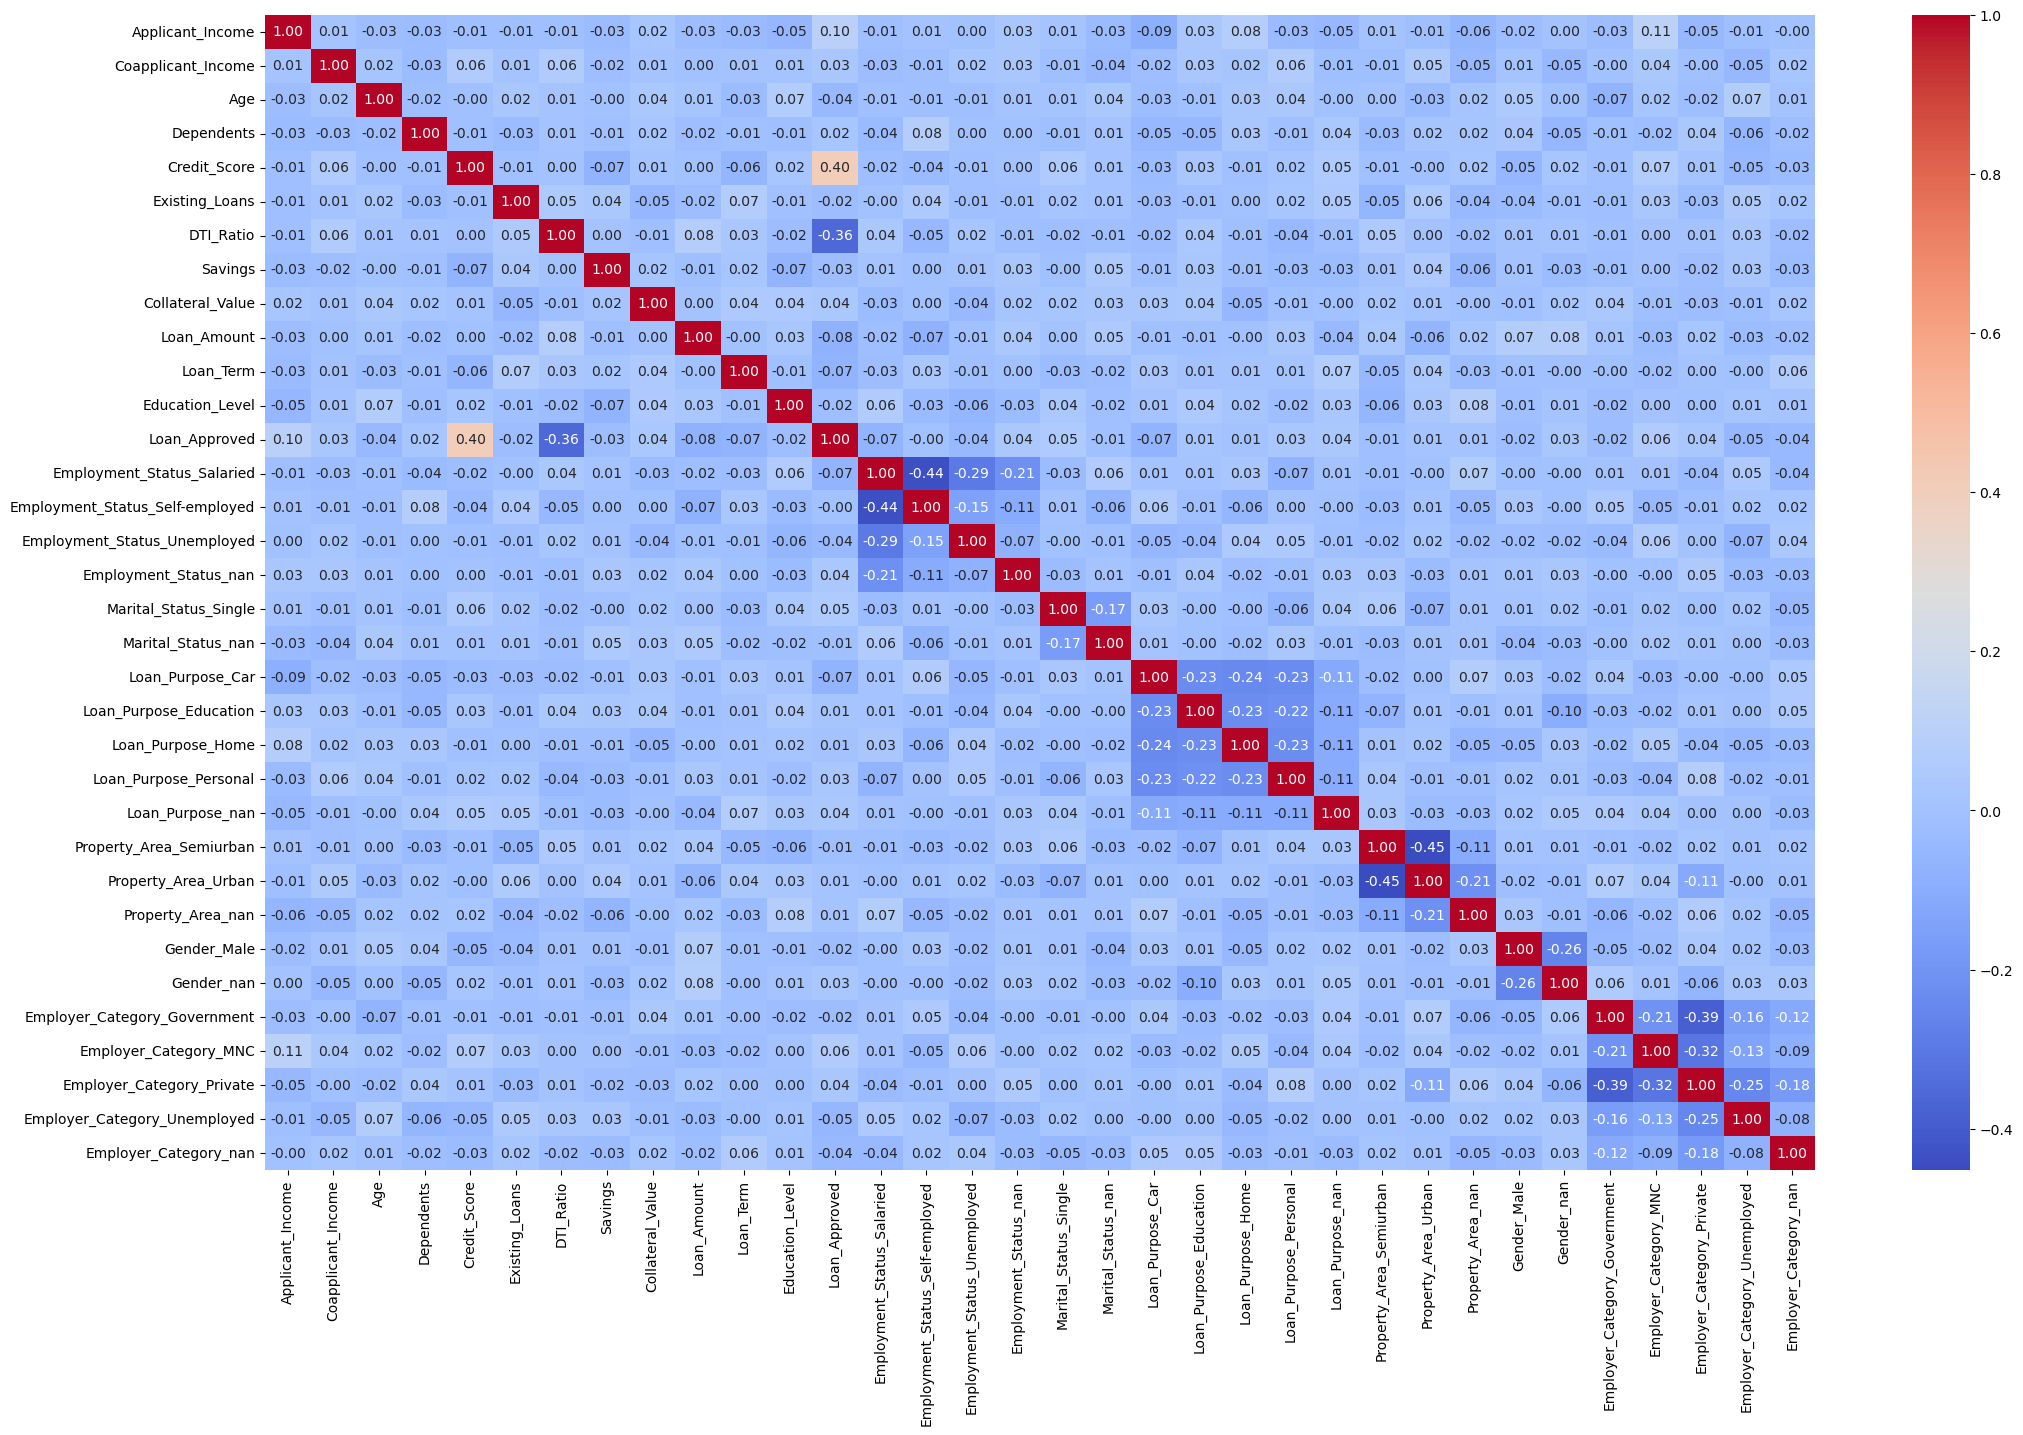

In [48]:
# Plotting the correlation matrix using heatmap

plt.figure(figsize=(25, 15))
sns.heatmap(
    corr_matrix, 
    annot = True,
    fmt = '.2f',
    cmap = "coolwarm"
)

#### >>> Train-Test-Split + Feature Scaling

In [49]:
X = data.drop("Loan_Approved", axis=1)
y = data['Loan_Approved']

X.head()
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)


In [52]:
# X_test.head()
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Property_Area_nan,Gender_Male,Gender_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan
29,5890.0,8041.0,31.0,0.0,603.0,0.0,0.11,11906.0,8150.0,29287.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
535,4779.0,529.0,50.0,0.0,614.0,0.0,0.21,5369.0,5430.0,14786.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
695,NaN,8927.0,36.0,0.0,584.0,4.0,0.22,3186.0,NaN,NaN,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
557,2384.0,2113.0,NaN,1.0,726.0,4.0,0.34,11882.0,48542.0,13312.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
836,5228.0,5249.0,42.0,1.0,NaN,NaN,0.18,17669.0,NaN,13906.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [53]:
# Feature scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [55]:
# X_train_scaled
X_test_scaled

array([[ 0.41443479,  0.53709858,  1.15784604, ..., -0.76841217,
        -0.30723158,  4.19578969],
       [ 0.9828934 ,  0.57518346,  0.17882655, ...,  1.30138491,
        -0.30723158, -0.23833416],
       [-0.65864379, -0.53233841,  1.06884427, ...,  1.30138491,
        -0.30723158, -0.23833416],
       ...,
       [-0.66276875, -0.09878288,  1.24684781, ...,  1.30138491,
        -0.30723158, -0.23833416],
       [-0.36734313, -0.95433247, -0.53318763, ..., -0.76841217,
        -0.30723158, -0.23833416],
       [-0.71796463, -1.21446579,  0.71283718, ...,  1.30138491,
        -0.30723158, -0.23833416]], shape=(200, 33))